# Hierarchical CRNN + SMOTE, v4 -- dual-embedding concatenation

v2 (fine-tuned backbone) and v3 (frozen backbone, classifier sweep) diagnosed a genuine split,
not a tuning artifact:

- **Frozen Phase A embeddings** (v1, v3): `focal_aware` (FA) separates well (50-100% recall
  across v3's whole sweep), but `focal_to_bilateral_tonic_clonic` (FBTC) never exceeds 0%
  recall in any of 16 classifier/SMOTE-ratio combinations tried.
- **Fine-tuned embeddings** (v2): FBTC separates well (45.9% recall, control-validated as real
  signal), but FA collapses to 0% -- fine-tuning distorts the representation FA needs, because
  it only has 29 real training windows (one patient, 3 events) to fine-tune from.

Neither representation alone supports both classes. This notebook tests the direct
consequence of that diagnosis: **concatenate both embeddings (128-d frozen + 128-d
fine-tuned = 256-d) so the classifier has access to whichever space actually separates each
class**, instead of forcing one representation to do both jobs. The fine-tuned backbone is
loaded from v2's saved checkpoint (`crnn_hierarchical_smote_v2/finetuned_backbone.pt`) --
nothing is retrained from scratch here except the final classifier, on the same corrected
split and per-class SMOTE approach v2/v3 already established.

Same selection discipline as v3: a rule fixed before looking at results (accuracy &ge; 0.90,
positive real-vs-control gap on both minority classes, then maximize minimum per-class
recall), swept across the same classifier families.

## Config

In [1]:
import json
import warnings
from itertools import product
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

WIN_ROOT = Path("../data/harmonized/windows")
PHASE_A_CKPT = Path("../checkpoints/crnn_hierarchical/phase_a_backbone_detector.pt")
FINETUNED_CKPT = Path("../checkpoints/crnn_hierarchical_smote_v2/finetuned_backbone.pt")
CKPT_DIR = Path("../checkpoints/crnn_hierarchical_smote_v4")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 20260803
TEST_FRAC = 0.3
CONTROL_WINDOWS_PER_PATIENT = 150

CNN_WIDTH = 32
RNN_HIDDEN = 64
RNN_LAYERS = 1
CNN_DROPOUT = 0.1
RNN_DROPOUT = 0.2
PHASE_A_HEAD_DROPOUT = 0.35
FT_HEAD_DROPOUT = 0.5

SMOTE_K_NEIGHBORS = 5
MIN_TEST_ACCURACY = 0.90

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))


device: cuda (NVIDIA GeForce RTX 5060 Ti)


## Data + corrected event-level split (identical to v2/v3)

In [2]:
S2 = pd.read_parquet(WIN_ROOT / "stage2_windows.parquet")
S1 = pd.read_parquet(WIN_ROOT / "stage1_windows.parquet")
MANIFEST = json.loads((WIN_ROOT / "manifest.json").read_text())

N_CH = MANIFEST["n_channels"]
N2_TIMEPOINTS = int(round(MANIFEST["stage2"]["window_s"] * MANIFEST["sfreq"]))
CLASS_NAMES = MANIFEST["stage2"]["class_names"]
CLASS_TO_IDX = MANIFEST["stage2"]["class_to_idx"]
SUBTYPE_BY_PATIENT = MANIFEST["subtype_by_patient"]
N_CLASSES = len(CLASS_NAMES)
stage2_patients = sorted(S2.subject.unique())


def event_stratified_split_v2(df, test_frac, seed):
    train_events, test_events = set(), set()
    for subtype, g in df.groupby("subtype"):
        ev = g.groupby("event_id").size().rename("n_windows").reset_index()
        ev = ev.sample(frac=1, random_state=seed).reset_index(drop=True)
        ev = ev.sort_values("n_windows", ascending=False, kind="stable").reset_index(drop=True)
        total = int(ev.n_windows.sum())
        target_test = total * test_frac
        target_train = total - target_test
        cum_train, cum_test = 0, 0
        train_ids, test_ids = [], []
        for row in ev.itertuples(index=False):
            test_deficit = target_test - cum_test
            train_deficit = target_train - cum_train
            if test_deficit >= train_deficit:
                test_ids.append(row.event_id); cum_test += row.n_windows
            else:
                train_ids.append(row.event_id); cum_train += row.n_windows
        if not test_ids:
            test_ids = [train_ids.pop()]
        if not train_ids:
            train_ids = [test_ids.pop()]
        train_events.update(train_ids)
        test_events.update(test_ids)
    assert not (train_events & test_events), "event leakage across splits"
    return train_events, test_events

train_events, test_events = event_stratified_split_v2(S2, TEST_FRAC, SEED)
train_df = S2[S2.event_id.isin(train_events)].reset_index(drop=True)
test_df = S2[S2.event_id.isin(test_events)].reset_index(drop=True)
print(f"train: {len(train_df):,} windows | test: {len(test_df):,} windows")


train: 1,274 windows | test: 550 windows


## Two backbones -- Phase A frozen, and v2's fine-tuned checkpoint (also frozen here)

Both are used purely as feature extractors in this notebook -- no further training of either
backbone happens. Only the classifier stage trains, on their concatenated output.

In [3]:
class CRNNBackbone(nn.Module):
    def __init__(self, n_channels=18, cnn_width=32, rnn_hidden=64, rnn_layers=1,
                 cnn_dropout=0.1, rnn_dropout=0.2):
        super().__init__()

        def block(c_in, c_out, k, stride):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.Dropout(cnn_dropout),
            )

        self.conv = nn.ModuleList([
            block(n_channels, cnn_width, 63, 2),
            block(cnn_width, cnn_width * 2, 31, 2),
            block(cnn_width * 2, cnn_width * 4, 15, 2),
            block(cnn_width * 4, cnn_width * 4, 7, 2),
        ])
        self.rnn = nn.LSTM(cnn_width * 4, rnn_hidden, num_layers=rnn_layers, batch_first=True,
                            bidirectional=True, dropout=rnn_dropout if rnn_layers > 1 else 0.0)
        self.attn = nn.Sequential(nn.Linear(rnn_hidden * 2, rnn_hidden), nn.Tanh(),
                                   nn.Linear(rnn_hidden, 1))
        self.out_dim = rnn_hidden * 2

    def forward(self, x):
        f = x
        for block in self.conv:
            f = block(f)
        f = f.transpose(1, 2)
        seq, _ = self.rnn(f)
        weights = torch.softmax(self.attn(seq).squeeze(-1), dim=1)
        return torch.bmm(weights.unsqueeze(1), seq).squeeze(1)


class HierarchicalCRNN(nn.Module):
    def __init__(self, n_channels=18, n_subtypes=3, cnn_width=32, rnn_hidden=64, rnn_layers=1,
                 cnn_dropout=0.1, rnn_dropout=0.2, head_dropout=0.35):
        super().__init__()
        self.backbone = CRNNBackbone(n_channels, cnn_width, rnn_hidden, rnn_layers,
                                      cnn_dropout, rnn_dropout)
        d = self.backbone.out_dim

        def head(n_out):
            return nn.Sequential(nn.Linear(d, d // 2), nn.ReLU(inplace=True),
                                  nn.Dropout(head_dropout), nn.Linear(d // 2, n_out))

        self.detect_head = head(1)
        self.subtype_head = head(n_subtypes)


ckpt_a = torch.load(PHASE_A_CKPT, map_location=DEVICE, weights_only=False)
_full = HierarchicalCRNN(N_CH, N_CLASSES, CNN_WIDTH, RNN_HIDDEN, RNN_LAYERS,
                          CNN_DROPOUT, RNN_DROPOUT, PHASE_A_HEAD_DROPOUT).to(DEVICE)
_full.load_state_dict(ckpt_a["model_state"])
frozen_backbone = _full.backbone.to(DEVICE).eval()
for p in frozen_backbone.parameters():
    p.requires_grad = False
del _full

ckpt_ft = torch.load(FINETUNED_CKPT, map_location=DEVICE, weights_only=False)
_full_ft = HierarchicalCRNN(N_CH, N_CLASSES, CNN_WIDTH, RNN_HIDDEN, RNN_LAYERS,
                             CNN_DROPOUT, RNN_DROPOUT, FT_HEAD_DROPOUT).to(DEVICE)
_full_ft.load_state_dict(ckpt_ft["model_state"])
finetuned_backbone = _full_ft.backbone.to(DEVICE).eval()
for p in finetuned_backbone.parameters():
    p.requires_grad = False
del _full_ft

EMBED_DIM = frozen_backbone.out_dim
print(f"frozen backbone: Phase A checkpoint (val AUROC {ckpt_a['val_auc']:.4f})")
print(f"fine-tuned backbone: v2 checkpoint (best epoch {ckpt_ft['best_epoch']}, val_macro_acc {ckpt_ft.get('val_macro_acc', float('nan')):.3f})")
print(f"per-backbone embedding dim: {EMBED_DIM} | concatenated dim: {EMBED_DIM * 2}")


frozen backbone: Phase A checkpoint (val AUROC 0.8164)
fine-tuned backbone: v2 checkpoint (best epoch 40, val_macro_acc 1.000)
per-backbone embedding dim: 128 | concatenated dim: 256


## Embedding extraction -- both backbones, then concatenated

In [4]:
class WindowDataset(Dataset):
    def __init__(self, df, n_timepoints):
        self.rows = df.reset_index(drop=True)
        self.n_timepoints = n_timepoints
        self._cache = {}

    def __len__(self):
        return len(self.rows)

    def _file(self, path):
        f = self._cache.get(path)
        if f is None:
            f = h5py.File(path, "r")
            self._cache[path] = f
        return f

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        sig = self._file(row.path)["signal"]
        start = int(row.start)
        end = min(start + self.n_timepoints, sig.shape[1])
        w = sig[:, start:end].astype(np.float32)
        if w.shape[1] < self.n_timepoints:
            w = np.pad(w, ((0, 0), (0, self.n_timepoints - w.shape[1])), mode="edge")
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        return torch.from_numpy((w - mu) / sd)


@torch.no_grad()
def embed_dual(df, n_timepoints, batch_size=128):
    ds = WindowDataset(df, n_timepoints)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    out = np.empty((len(df), EMBED_DIM * 2), dtype=np.float32)
    i = 0
    for x in loader:
        xb = x.to(DEVICE)
        e1 = frozen_backbone(xb).cpu().numpy()
        e2 = finetuned_backbone(xb).cpu().numpy()
        e = np.concatenate([e1, e2], axis=1)
        out[i:i + len(e)] = e
        i += len(e)
    return out

emb_train = embed_dual(train_df, N2_TIMEPOINTS)
emb_test = embed_dual(test_df, N2_TIMEPOINTS)
y_train = train_df.subtype.map(CLASS_TO_IDX).to_numpy()
y_test = test_df.subtype.map(CLASS_TO_IDX).to_numpy()
subj_test = test_df.subject.to_numpy()


def build_adversarial_control(s1_df, subtype_by_patient, patients, max_per_patient, seed):
    neg = s1_df[(s1_df.dataset == "SienaScalp") & (s1_df.label == 0) & (s1_df.subject.isin(patients))]
    parts = [g.sample(min(len(g), max_per_patient), random_state=seed) for _, g in neg.groupby("subject")]
    ctrl = pd.concat(parts).reset_index(drop=True)
    ctrl["subtype"] = ctrl.subject.map(subtype_by_patient)
    return ctrl


def control_stratified_split(df, test_frac, seed):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for (subtype, subject), g in df.groupby(["subtype", "subject"]):
        idx = rng.permutation(g.index.to_numpy())
        n_test = max(1, int(round(len(idx) * test_frac)))
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])
    return df.loc[train_idx].reset_index(drop=True), df.loc[test_idx].reset_index(drop=True)

control_df = build_adversarial_control(S1, SUBTYPE_BY_PATIENT, stage2_patients, CONTROL_WINDOWS_PER_PATIENT, SEED)
ctrl_train_df, ctrl_test_df = control_stratified_split(control_df, TEST_FRAC, SEED)
emb_ctrl_train = embed_dual(ctrl_train_df, N2_TIMEPOINTS)
emb_ctrl_test = embed_dual(ctrl_test_df, N2_TIMEPOINTS)
y_ctrl_train = ctrl_train_df.subtype.map(CLASS_TO_IDX).to_numpy()
y_ctrl_test = ctrl_test_df.subtype.map(CLASS_TO_IDX).to_numpy()
subj_ctrl_test = ctrl_test_df.subject.to_numpy()

print(f"real: train {emb_train.shape} test {emb_test.shape} | control: train {emb_ctrl_train.shape} test {emb_ctrl_test.shape}")


real: train (1274, 256) test (550, 256) | control: train (1365, 256) test (585, 256)


## Classifier + SMOTE-ratio sweep, on the concatenated 256-d embeddings

In [5]:
def smote_balance(X, y, ratio_map, k_neighbors, seed):
    counts = pd.Series(y).value_counts()
    majority_count = counts.max()
    strategy = {}
    for cls, n in counts.items():
        if n >= majority_count:
            continue
        name = CLASS_NAMES[cls]
        ratio = ratio_map.get(name, 3)
        strategy[cls] = int(min(majority_count, n * ratio))
    k = max(1, min(k_neighbors, counts.min() - 1))
    sm = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=seed)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res


class TorchMLP:
    def __init__(self, in_dim, n_classes, hidden, dropout, seed, lr=1e-3, weight_decay=3e-3,
                 batch_size=64, max_epochs=300, patience=25, min_epochs=30, val_frac=0.15):
        self.in_dim, self.n_classes, self.hidden, self.dropout = in_dim, n_classes, hidden, dropout
        self.seed, self.lr, self.weight_decay = seed, lr, weight_decay
        self.batch_size, self.max_epochs, self.patience = batch_size, max_epochs, patience
        self.min_epochs, self.val_frac = min_epochs, val_frac

    def _net(self):
        return nn.Sequential(nn.Linear(self.in_dim, self.hidden), nn.ReLU(inplace=True),
                              nn.Dropout(self.dropout), nn.Linear(self.hidden, self.n_classes)).to(DEVICE)

    def fit(self, X, y, real_mask):
        rng = np.random.default_rng(self.seed)
        real_idx = np.where(real_mask)[0]
        val_idx = []
        for cls in np.unique(y[real_idx]):
            idx = real_idx[y[real_idx] == cls]
            n_val = max(1, int(round(len(idx) * self.val_frac)))
            val_idx.extend(rng.choice(idx, size=n_val, replace=False))
        val_mask = np.zeros(len(y), dtype=bool); val_mask[val_idx] = True
        train_rows = np.where(~val_mask)[0]

        Xtr = torch.from_numpy(X[train_rows]).to(DEVICE)
        ytr = torch.from_numpy(y[train_rows]).long().to(DEVICE)
        Xval = torch.from_numpy(X[val_idx]).to(DEVICE)
        yval = torch.from_numpy(y[val_idx]).long().to(DEVICE)

        torch.manual_seed(self.seed)
        self.model = self._net()
        opt = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        crit = nn.CrossEntropyLoss()
        n_train = Xtr.size(0)
        best_val, best_state, bad = -1.0, None, 0
        for epoch in range(self.max_epochs):
            self.model.train()
            perm = torch.randperm(n_train, device=DEVICE)
            for start in range(0, n_train, self.batch_size):
                idx = perm[start:start + self.batch_size]
                xb, yb = Xtr[idx], ytr[idx]
                loss = crit(self.model(xb), yb)
                opt.zero_grad(); loss.backward(); opt.step()
            self.model.eval()
            with torch.no_grad():
                val_acc = (self.model(Xval).argmax(1) == yval).float().mean().item()
            if val_acc >= best_val:
                best_val, bad = val_acc, 0
                best_state = {k: v.detach().clone() for k, v in self.model.state_dict().items()}
            else:
                bad += 1
            if epoch + 1 >= self.min_epochs and bad >= self.patience:
                break
        self.model.load_state_dict(best_state)
        self.model.eval()
        return self

    def predict(self, X):
        with torch.no_grad():
            return self.model(torch.from_numpy(X).to(DEVICE)).argmax(1).cpu().numpy()


def make_classifier(kind, seed):
    if kind == "mlp":
        return TorchMLP(EMBED_DIM * 2, N_CLASSES, hidden=96, dropout=0.5, seed=seed)
    if kind == "random_forest":
        return RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=2,
                                       class_weight="balanced", random_state=seed, n_jobs=-1)
    if kind == "hist_gb":
        return HistGradientBoostingClassifier(max_depth=4, learning_rate=0.08, max_iter=200,
                                               l2_regularization=0.5, random_state=seed)
    raise ValueError(kind)


RATIO_GRID = [
    {"focal_aware": 3, "focal_to_bilateral_tonic_clonic": 3},
    {"focal_aware": 3, "focal_to_bilateral_tonic_clonic": 5},
    {"focal_aware": 5, "focal_to_bilateral_tonic_clonic": 5},
]
CLASSIFIER_GRID = ["mlp", "random_forest", "hist_gb"]

results = []
for clf_kind, ratio_map in product(CLASSIFIER_GRID, RATIO_GRID):
    Xb, yb = smote_balance(emb_train, y_train, ratio_map, SMOTE_K_NEIGHBORS, SEED)
    real_mask = np.zeros(len(yb), dtype=bool); real_mask[:len(y_train)] = True
    clf = make_classifier(clf_kind, SEED)
    if clf_kind == "mlp":
        clf.fit(Xb, yb, real_mask)
    else:
        clf.fit(Xb, yb)
    pred = clf.predict(emb_test)

    Xb_c, yb_c = smote_balance(emb_ctrl_train, y_ctrl_train, ratio_map, SMOTE_K_NEIGHBORS, SEED)
    real_mask_c = np.zeros(len(yb_c), dtype=bool); real_mask_c[:len(y_ctrl_train)] = True
    clf_c = make_classifier(clf_kind, SEED)
    if clf_kind == "mlp":
        clf_c.fit(Xb_c, yb_c, real_mask_c)
    else:
        clf_c.fit(Xb_c, yb_c)
    pred_c = clf_c.predict(emb_ctrl_test)

    acc = (pred == y_test).mean()
    macro_f1 = f1_score(y_test, pred, average="macro", zero_division=0)
    per_class_recall = recall_score(y_test, pred, average=None, labels=list(range(N_CLASSES)), zero_division=0)
    ctrl_acc = (pred_c == y_ctrl_test).mean()
    ctrl_per_class_recall = recall_score(y_ctrl_test, pred_c, average=None, labels=list(range(N_CLASSES)), zero_division=0)

    results.append({
        "classifier": clf_kind, "ratio": ratio_map, "accuracy": acc, "macro_f1": macro_f1,
        "recall_focal_aware": per_class_recall[0], "recall_fia": per_class_recall[1],
        "recall_fbtc": per_class_recall[2], "min_recall": per_class_recall.min(),
        "control_accuracy": ctrl_acc,
        "gap_fa": per_class_recall[0] - ctrl_per_class_recall[0],
        "gap_fbtc": per_class_recall[2] - ctrl_per_class_recall[2],
    })

res_df = pd.DataFrame(results)
pd.set_option("display.width", 160)
print(res_df.sort_values("min_recall", ascending=False).to_string(index=False))


   classifier                                                    ratio  accuracy  macro_f1  recall_focal_aware  recall_fia  recall_fbtc  min_recall  control_accuracy    gap_fa  gap_fbtc
      hist_gb {'focal_aware': 3, 'focal_to_bilateral_tonic_clonic': 5}  0.910909  0.611648              0.2500    0.961771     0.513514      0.2500          0.789744  0.116667  0.069069
      hist_gb {'focal_aware': 5, 'focal_to_bilateral_tonic_clonic': 5}  0.912727  0.595929              0.1250    0.961771     0.594595      0.1250          0.769231 -0.008333  0.172372
      hist_gb {'focal_aware': 3, 'focal_to_bilateral_tonic_clonic': 3}  0.905455  0.529414              0.0625    0.969819     0.405405      0.0625          0.789744 -0.048611  0.027628
          mlp {'focal_aware': 3, 'focal_to_bilateral_tonic_clonic': 3}  0.905455  0.534387              0.0000    0.965795     0.486486      0.0000          0.846154  0.000000  0.486486
          mlp {'focal_aware': 3, 'focal_to_bilateral_tonic_clonic': 5}

## Selecting the winner

Same rule as v3, fixed in advance: accuracy &ge; 0.90, positive real-vs-control gap on both
minority classes, then maximize minimum per-class recall. If nothing clears the accuracy bar
this time either, that itself is the answer to whether balanced 3-class recall at 90%+
accuracy is achievable with this dataset and these representations -- not a reason to weaken
the rule after seeing results.

In [6]:
eligible = res_df[(res_df.accuracy >= MIN_TEST_ACCURACY) & (res_df.gap_fa > 0) & (res_df.gap_fbtc > 0)]
print(f"{len(eligible)} / {len(res_df)} candidates clear accuracy>={MIN_TEST_ACCURACY} with real signal on both minority classes\n")
print(eligible.sort_values("min_recall", ascending=False).to_string(index=False))

acc_pool = res_df[res_df.accuracy >= MIN_TEST_ACCURACY]
print(f"\n{len(acc_pool)} / {len(res_df)} candidates clear accuracy>={MIN_TEST_ACCURACY} (ignoring the control-gap requirement)")
print(acc_pool.sort_values("min_recall", ascending=False).to_string(index=False))

if len(eligible) > 0:
    winner = eligible.sort_values("min_recall", ascending=False).iloc[0]
    winner_note = "meets both the accuracy floor and the real-signal requirement on both minority classes"
elif len(acc_pool) > 0:
    winner = acc_pool.sort_values("min_recall", ascending=False).iloc[0]
    winner_note = "meets the accuracy floor but NOT the real-signal requirement on both minority classes -- flagged, not hidden"
else:
    winner = res_df.sort_values("accuracy", ascending=False).iloc[0]
    winner_note = "NO candidate cleared accuracy>=0.90 at all -- reporting the highest-accuracy candidate as the honest ceiling of this approach"

print(f"\nWINNER: {winner['classifier']}  ratio={winner['ratio']}  accuracy={winner['accuracy']:.3f}  "
      f"macro_f1={winner['macro_f1']:.3f}  min_recall={winner['min_recall']:.3f}")
print(winner_note)


1 / 9 candidates clear accuracy>=0.9 with real signal on both minority classes

classifier                                                    ratio  accuracy  macro_f1  recall_focal_aware  recall_fia  recall_fbtc  min_recall  control_accuracy   gap_fa  gap_fbtc
   hist_gb {'focal_aware': 3, 'focal_to_bilateral_tonic_clonic': 5}  0.910909  0.611648                0.25    0.961771     0.513514        0.25          0.789744 0.116667  0.069069

6 / 9 candidates clear accuracy>=0.9 (ignoring the control-gap requirement)
classifier                                                    ratio  accuracy  macro_f1  recall_focal_aware  recall_fia  recall_fbtc  min_recall  control_accuracy    gap_fa  gap_fbtc
   hist_gb {'focal_aware': 3, 'focal_to_bilateral_tonic_clonic': 5}  0.910909  0.611648              0.2500    0.961771     0.513514      0.2500          0.789744  0.116667  0.069069
   hist_gb {'focal_aware': 5, 'focal_to_bilateral_tonic_clonic': 5}  0.912727  0.595929              0.1250    0.

## Full report for the winning configuration

In [7]:
def report(true, pred, subj_arr, tag):
    print(f"\n{'=' * 60}\n{tag}\n{'=' * 60}")
    print(classification_report(true, pred, target_names=CLASS_NAMES, labels=list(range(N_CLASSES)),
                                 digits=3, zero_division=0))
    cm = confusion_matrix(true, pred, labels=list(range(N_CLASSES)))
    print("confusion matrix (rows=true, cols=predicted):")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    if subj_arr is not None:
        ev = pd.DataFrame({"subject": subj_arr, "true": true, "pred": pred})
        per_patient = ev.groupby("subject").apply(lambda g: (g.true == g.pred).mean(), include_groups=False)
        print(f"\nper-patient (window-level) accuracy:"); print(per_patient.rename("window_accuracy"))
    return cm

winner_kind, winner_ratio = winner["classifier"], winner["ratio"]

Xb, yb = smote_balance(emb_train, y_train, winner_ratio, SMOTE_K_NEIGHBORS, SEED)
real_mask = np.zeros(len(yb), dtype=bool); real_mask[:len(y_train)] = True
final_clf = make_classifier(winner_kind, SEED)
if winner_kind == "mlp":
    final_clf.fit(Xb, yb, real_mask)
else:
    final_clf.fit(Xb, yb)
final_pred = final_clf.predict(emb_test)

Xb_c, yb_c = smote_balance(emb_ctrl_train, y_ctrl_train, winner_ratio, SMOTE_K_NEIGHBORS, SEED)
real_mask_c = np.zeros(len(yb_c), dtype=bool); real_mask_c[:len(y_ctrl_train)] = True
final_clf_c = make_classifier(winner_kind, SEED)
if winner_kind == "mlp":
    final_clf_c.fit(Xb_c, yb_c, real_mask_c)
else:
    final_clf_c.fit(Xb_c, yb_c)
final_pred_c = final_clf_c.predict(emb_ctrl_test)

real_cm = report(y_test, final_pred, subj_test, f"REAL -- {winner_kind}, ratio={winner_ratio}")
real_acc = (y_test == final_pred).mean()
real_f1 = f1_score(y_test, final_pred, average="macro", zero_division=0)
print(f"\naccuracy={real_acc:.3f}  macro-F1={real_f1:.3f}")

ctrl_cm = report(y_ctrl_test, final_pred_c, subj_ctrl_test, "ADVERSARIAL CONTROL")
ctrl_acc = (y_ctrl_test == final_pred_c).mean()
ctrl_f1 = f1_score(y_ctrl_test, final_pred_c, average="macro", zero_division=0)
print(f"\naccuracy={ctrl_acc:.3f}  macro-F1={ctrl_f1:.3f}")



REAL -- hist_gb, ratio={'focal_aware': 3, 'focal_to_bilateral_tonic_clonic': 5}
                                 precision    recall  f1-score   support

                    focal_aware      0.174     0.250     0.205        16
       focal_impaired_awareness      0.941     0.962     0.951       497
focal_to_bilateral_tonic_clonic      1.000     0.514     0.679        37

                       accuracy                          0.911       550
                      macro avg      0.705     0.575     0.612       550
                   weighted avg      0.923     0.911     0.911       550

confusion matrix (rows=true, cols=predicted):
                                 focal_aware  focal_impaired_awareness  focal_to_bilateral_tonic_clonic
focal_aware                                4                        12                                0
focal_impaired_awareness                  19                       478                                0
focal_to_bilateral_tonic_clonic            0   

## Summary vs. every prior model

                                          accuracy  macro-F1
LOSO real                                    0.893     0.314
v1 synthesis real                            0.933     0.450
v2 (fine-tuned backbone) real                0.907     0.526
v3 (frozen backbone sweep) real              0.573     0.374
v4 (this notebook, dual-embedding) real      0.911     0.612
v4 (this notebook) control                   0.790     0.475


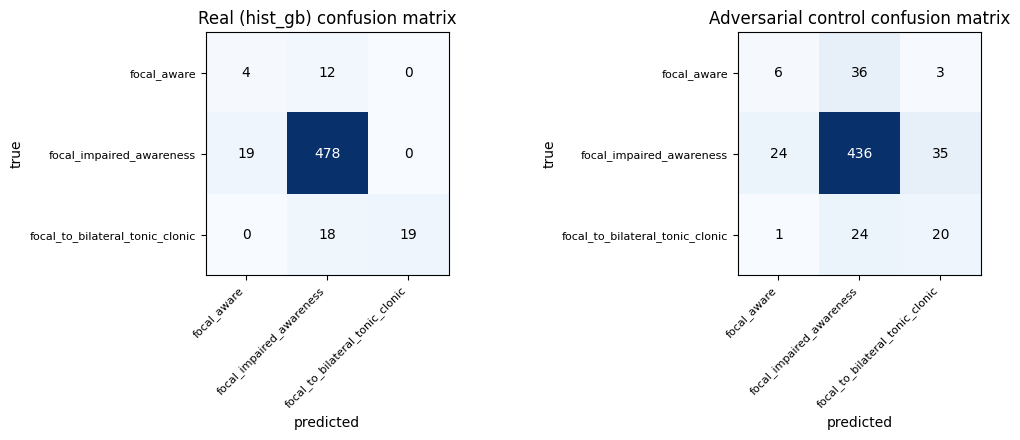


summary written to ..\checkpoints\crnn_hierarchical_smote_v4\v4_summary.json


In [8]:
print(f"{'':40s}{'accuracy':>10}{'macro-F1':>10}")
print(f"{'LOSO real':40s}{0.893:>10.3f}{0.314:>10.3f}")
print(f"{'v1 synthesis real':40s}{0.933:>10.3f}{0.450:>10.3f}")
print(f"{'v2 (fine-tuned backbone) real':40s}{0.907:>10.3f}{0.526:>10.3f}")
print(f"{'v3 (frozen backbone sweep) real':40s}{0.573:>10.3f}{0.374:>10.3f}")
print(f"{'v4 (this notebook, dual-embedding) real':40s}{real_acc:>10.3f}{real_f1:>10.3f}")
print(f"{'v4 (this notebook) control':40s}{ctrl_acc:>10.3f}{ctrl_f1:>10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in [(axes[0], real_cm, f"Real ({winner_kind})"), (axes[1], ctrl_cm, "Adversarial control")]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{title} confusion matrix")
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(CKPT_DIR / "v4_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

summary = {
    "protocol": "dual-embedding concatenation (frozen Phase A + v2 fine-tuned backbone) + classifier/SMOTE sweep",
    "winner_classifier": winner_kind, "winner_ratio": winner_ratio, "winner_note": winner_note,
    "real_accuracy": float(real_acc), "real_macro_f1": float(real_f1),
    "control_accuracy": float(ctrl_acc), "control_macro_f1": float(ctrl_f1),
    "sweep_results": res_df.to_dict(orient="records"),
    "v3_baseline": {"real_accuracy": 0.573, "real_macro_f1": 0.374},
    "v2_baseline": {"real_accuracy": 0.907, "real_macro_f1": 0.526},
    "v1_baseline": {"real_accuracy": 0.933, "real_macro_f1": 0.450},
    "loso_baseline": {"real_accuracy": 0.893, "real_macro_f1": 0.314},
}
(CKPT_DIR / "v4_summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(f"\nsummary written to {CKPT_DIR / 'v4_summary.json'}")
